In [15]:
print('Đang khai báo thư viện')

import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('Khai báo thư viện thành công')

Đang khai báo thư viện
Khai báo thư viện thành công


In [30]:
print('Khai báo dữ liệu')

train_path = "data_train_cleaned.csv"

train_path = os.path.join("..", "Data", "DataCleaned", "data_train_cleaned.csv")
val_path = os.path.join("..", "Data", "DataCleaned", "validation_cleaned.csv")

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)

print("THÔNG TIN DỮ LIỆU")

print(f"Train shape: {df_train.shape}")
print(f"Validation shape: {df_val.shape}")
print(f"\nTrain columns:\n{df_train.columns.tolist()}")
print(f"\nClass distribution trong train:\n{df_train['Class'].value_counts().sort_index()}")
print(f"\nClass distribution trong validation:\n{df_val['Class'].value_counts().sort_index()}")

Khai báo dữ liệu
THÔNG TIN DỮ LIỆU
Train shape: (11516, 20)
Validation shape: (2880, 17)

Train columns:
['Id', 'Artist Name', 'Track Name', 'Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'Class', 'key_sin', 'key_cos']

Class distribution trong train:
Class
0      400
1      878
2      814
3      258
4      248
5      926
6     1655
7      369
8     1186
9     1615
10    3167
Name: count, dtype: int64

Class distribution trong validation:
Class
0     100
1     220
2     204
3      64
4      62
5     231
6     414
7      92
8     297
9     404
10    792
Name: count, dtype: int64


In [31]:
train_dist = y_train.value_counts(normalize=True).sort_index().rename('train_%')
val_dist   = y_val.value_counts(normalize=True).sort_index().rename('val_%')
print(pd.concat([train_dist, val_dist], axis=1).round(4))

       train_%   val_%
Class                 
0       0.0347  0.0347
1       0.0762  0.0764
2       0.0707  0.0708
3       0.0224  0.0222
4       0.0215  0.0215
5       0.0804  0.0802
6       0.1437  0.1438
7       0.0320  0.0319
8       0.1030  0.1031
9       0.1402  0.1403
10      0.2750  0.2750


In [18]:
# So sánh mean của từng feature giữa train và validation
compare = pd.DataFrame({
    'train_mean': X_train.mean(),
    'val_mean'  : X_val.mean(),
    'diff_pct'  : ((X_train.mean() - X_val.mean()) / X_train.mean() * 100).round(2)
})
print(compare.sort_values('diff_pct', key=abs, ascending=False))

                     train_mean       val_mean  diff_pct
key_sin                0.010156       0.025233   -148.45
instrumentalness       0.135972       0.132591      2.49
mode                   0.637635       0.650694     -2.05
valence                0.484816       0.492630     -1.61
key_cos               -0.186101      -0.188528     -1.30
Popularity            44.629298      44.048264      1.30
key                    6.083015       6.021528      1.01
duration_ms       234063.474870  232018.650311      0.87
danceability           0.543655       0.540908      0.51
liveness               0.195609       0.196473     -0.44
time_signature         3.927058       3.913542      0.34
loudness              -7.864334      -7.886753     -0.29
speechiness            0.080222       0.080017      0.26
tempo                122.739634     122.510843      0.19
energy                 0.662289       0.662952     -0.10
acousticness           0.246707       0.246902     -0.08


In [19]:
# Bỏ các cột không cần thiết (nếu có)
drop_cols = ['Id', 'Artist Name', 'Track Name']
existing_drop_train = [col for col in drop_cols if col in df_train.columns]
existing_drop_val = [col for col in drop_cols if col in df_val.columns]

X_train = df_train.drop(columns=['Class'] + existing_drop_train)
y_train = df_train['Class']

X_val = df_val.drop(columns=['Class'] + existing_drop_val)
y_val = df_val['Class']

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")


X_train shape: (11516, 16)
X_val shape: (2880, 16)


In [20]:
# ── STEP 1: Train model ────────────────────────────────────────────────────

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("✅ Train xong!")
print(f"   n_estimators : {rf.n_estimators}")
print(f"   class_weight : balanced")
print(f"   n_features   : {rf.n_features_in_}")

✅ Train xong!
   n_estimators : 200
   class_weight : balanced
   n_features   : 16


In [21]:
# ── STEP 1.5: GridSearchCV để tìm hyperparameters tốt nhất ────────────────────

from sklearn.model_selection import GridSearchCV

print("\n🔍 Bắt đầu GridSearchCV để tìm hyperparameters tối ưu...")
print("⏱️  Quá trình này có thể mất vài phút (tùy vào dữ liệu)\n")

param_grid = {
    'n_estimators'    : [200, 500],
    'max_depth'       : [10, 15, 20],
    'min_samples_leaf': [5, 10, 20],
    'max_features'    : ['sqrt', 0.3]
}

rf_tuned = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    rf_tuned,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("\n" + "="*55)
print("KẾT QUẢ GRIDSEARCH")
print("="*55)
print("Best params:", grid_search.best_params_)
print("Best CV F1 macro (5-fold):", grid_search.best_score_)

# Đánh giá với best model
best_rf = grid_search.best_estimator_
y_pred_val_tuned = best_rf.predict(X_val)

print("\n=== SAU KHI TUNE (dùng best model từ GridSearch) ===")
print(f"Accuracy  Validation : {accuracy_score(y_val, y_pred_val_tuned):.4f}")
print(f"Macro F1  Validation : {f1_score(y_val, y_pred_val_tuned, average='macro', zero_division=0):.4f}")
print("\nClassification Report trên Validation:")
print(classification_report(y_val, y_pred_val_tuned, zero_division=0))


🔍 Bắt đầu GridSearchCV để tìm hyperparameters tối ưu...
⏱️  Quá trình này có thể mất vài phút (tùy vào dữ liệu)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

KẾT QUẢ GRIDSEARCH
Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 500}
Best CV F1 macro (5-fold): 0.4466420912887653

=== SAU KHI TUNE (dùng best model từ GridSearch) ===
Accuracy  Validation : 0.4399
Macro F1  Validation : 0.4410

Classification Report trên Validation:
              precision    recall  f1-score   support

           0       0.23      0.43      0.30       100
           1       0.03      0.01      0.02       220
           2       0.34      0.47      0.39       204
           3       0.41      0.59      0.48        64
           4       0.31      0.56      0.40        62
           5       0.67      0.75      0.71       231
           6       0.33      0.24      0.28       414
           7       0.66      0.92      0.77        92
           8      

In [22]:
# ── STEP 2: Predict ────────────────────────────────────────────────────────

y_pred_train = rf.predict(X_train)
y_pred_val   = rf.predict(X_val)

acc_train = accuracy_score(y_train, y_pred_train)
acc_val   = accuracy_score(y_val, y_pred_val)

print("=" * 55)
print("ACCURACY")
print("=" * 55)
print(f"  Train      : {acc_train:.4f} ({acc_train*100:.2f}%)")
print(f"  Validation : {acc_val:.4f} ({acc_val*100:.2f}%)")
print(f"  Gap        : {acc_train - acc_val:.4f}  ", end="")
if acc_train - acc_val > 0.1:
    print("⚠️  Có dấu hiệu Overfitting")
elif acc_val < 0.5:
    print("⚠️  Model yếu — Underfitting")
else:
    print("✅ Ổn định")

ACCURACY
  Train      : 0.9168 (91.68%)
  Validation : 0.4524 (45.24%)
  Gap        : 0.4644  ⚠️  Có dấu hiệu Overfitting


In [23]:
# ── STEP 3: Classification Report ─────────────────────────────────────────

print("=" * 55)
print("CLASSIFICATION REPORT — TRAIN")
print("=" * 55)
print(classification_report(y_train, y_pred_train, zero_division=0))

print("=" * 55)
print("CLASSIFICATION REPORT — VALIDATION")
print("=" * 55)
print(classification_report(y_val, y_pred_val, zero_division=0))

CLASSIFICATION REPORT — TRAIN
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       400
           1       0.68      0.95      0.79       878
           2       0.95      0.99      0.97       814
           3       0.94      1.00      0.97       258
           4       0.96      1.00      0.98       248
           5       0.92      0.99      0.95       926
           6       0.94      0.81      0.87      1655
           7       0.90      1.00      0.95       369
           8       0.91      0.99      0.95      1186
           9       0.94      0.94      0.94      1615
          10       0.99      0.85      0.91      3167

    accuracy                           0.92     11516
   macro avg       0.91      0.96      0.93     11516
weighted avg       0.93      0.92      0.92     11516

CLASSIFICATION REPORT — VALIDATION
              precision    recall  f1-score   support

           0       0.31      0.35      0.33       100
           1 

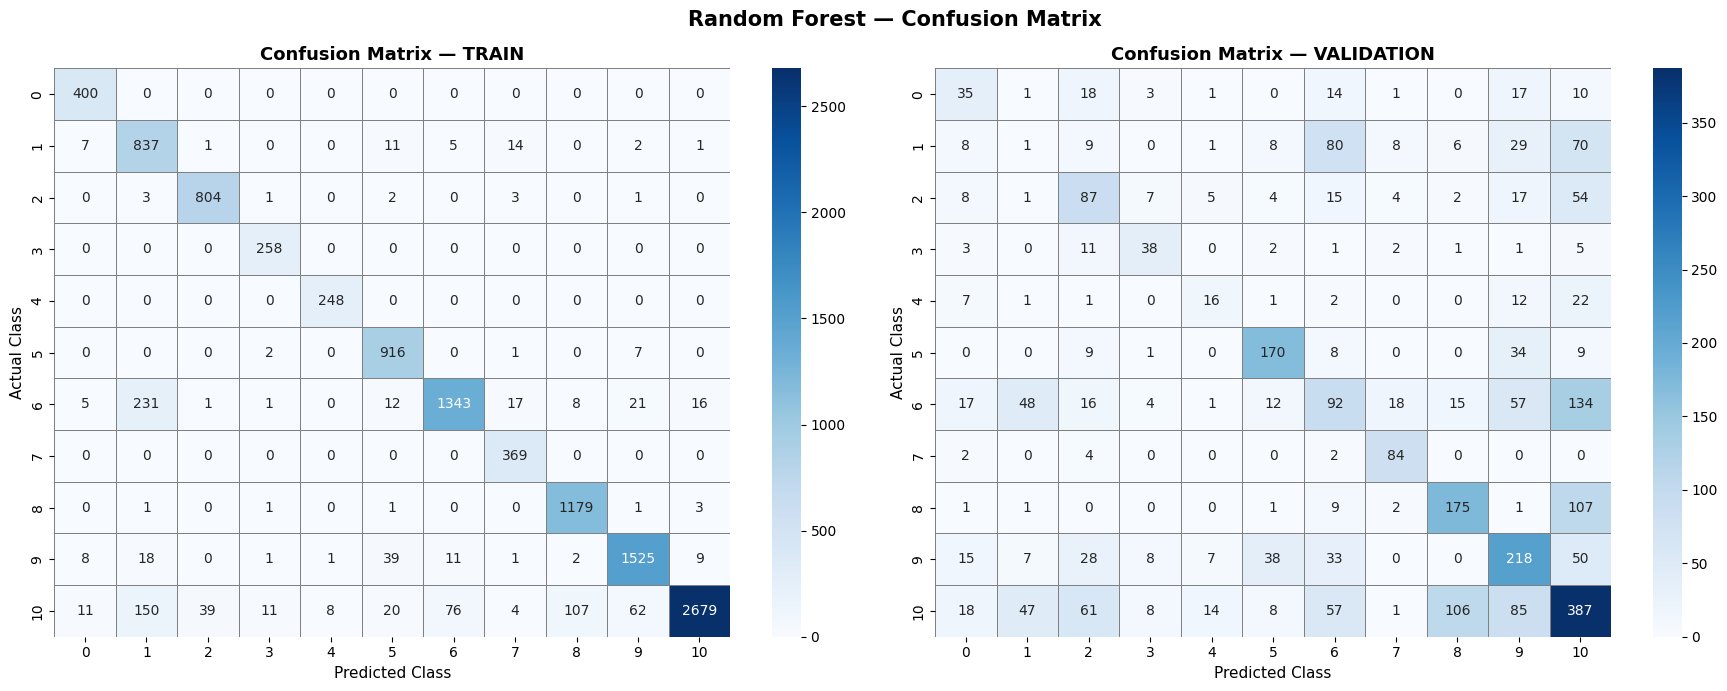

In [24]:
# ── STEP 4: Confusion Matrix ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_val],
    [y_pred_train, y_pred_val],
    ['Confusion Matrix — TRAIN', 'Confusion Matrix — VALIDATION']
):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=sorted(y_train.unique()),
                yticklabels=sorted(y_train.unique()),
                linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Predicted Class', fontsize=11)
    ax.set_ylabel('Actual Class', fontsize=11)

plt.suptitle('Random Forest — Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

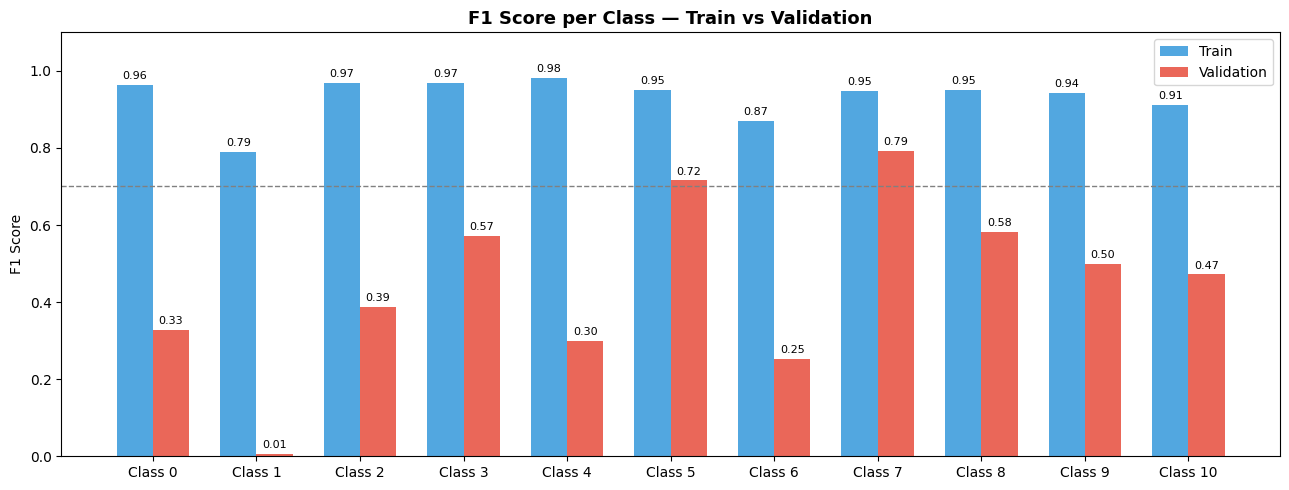

Class yếu nhất trên Validation (F1 < 0.7):
  Class  0: F1 = 0.3271
  Class  1: F1 = 0.0061
  Class  2: F1 = 0.3884
  Class  3: F1 = 0.5714
  Class  4: F1 = 0.2991
  Class  6: F1 = 0.2531
  Class  8: F1 = 0.5814
  Class  9: F1 = 0.4983
  Class 10: F1 = 0.4720


In [25]:
# ── STEP 5: Per-class F1 Score — Train vs Validation ──────────────────────

from sklearn.metrics import f1_score

classes = sorted(y_train.unique())
f1_train = f1_score(y_train, y_pred_train, average=None, labels=classes, zero_division=0)
f1_val   = f1_score(y_val,   y_pred_val,   average=None, labels=classes, zero_division=0)

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, f1_train, width, label='Train',      color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_val,   width, label='Validation', color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Class {c}' for c in classes])
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('F1 Score per Class — Train vs Validation', fontweight='bold', fontsize=13)
ax.legend()
ax.axhline(0.7, color='gray', linestyle='--', linewidth=1, label='threshold 0.7')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# In ra class nào yếu nhất
print("Class yếu nhất trên Validation (F1 < 0.7):")
for c, f1 in zip(classes, f1_val):
    if f1 < 0.7:
        print(f"  Class {c:>2d}: F1 = {f1:.4f}")

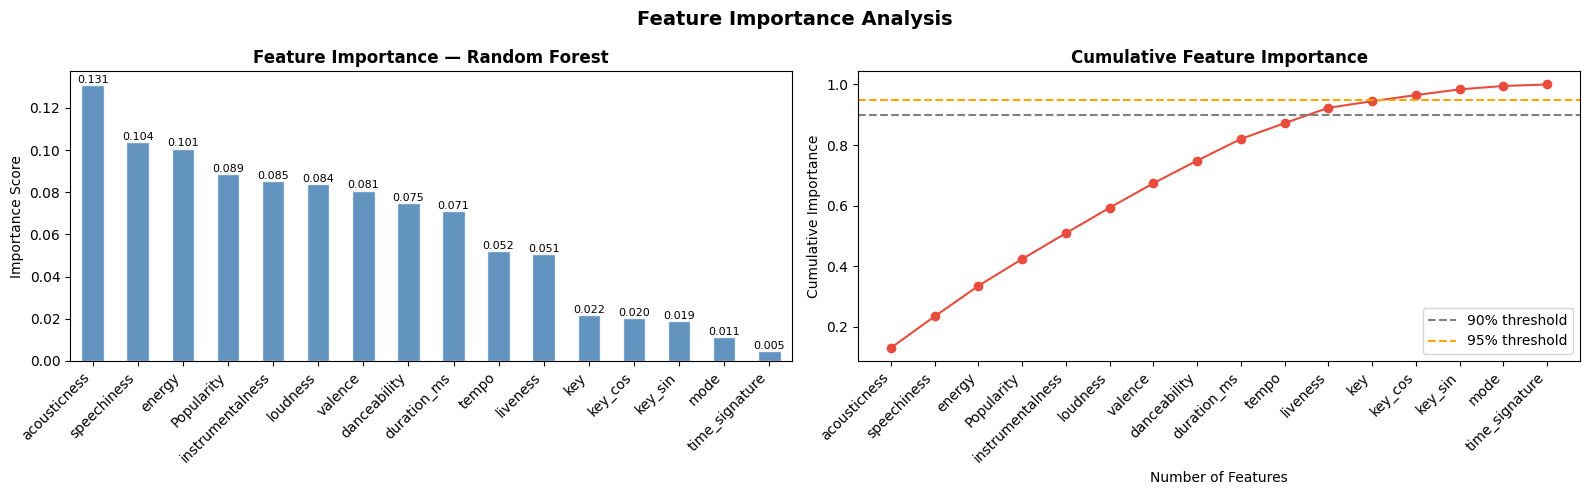


Top 5 features quan trọng nhất:
  acousticness             : 0.1308
  speechiness              : 0.1038
  energy                   : 0.1007
  Popularity               : 0.0887
  instrumentalness         : 0.0852

→ Chỉ cần 11 features để giải thích 90% importance


In [26]:
# ── STEP 6: Feature Importance ─────────────────────────────────────────────

feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
feat_imp.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[0].set_ylabel('Importance Score')
axes[0].set_xticklabels(feat_imp.index, rotation=45, ha='right')
for i, v in enumerate(feat_imp.values):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=8)

# Cumulative importance
cumsum = feat_imp.cumsum()
axes[1].plot(range(1, len(cumsum)+1), cumsum.values, marker='o', color='#e74c3c')
axes[1].axhline(0.9, color='gray', linestyle='--', label='90% threshold')
axes[1].axhline(0.95, color='orange', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Feature Importance', fontweight='bold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_xticks(range(1, len(cumsum)+1))
axes[1].set_xticklabels(feat_imp.index, rotation=45, ha='right')
axes[1].legend()

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 features quan trọng nhất:")
for feat, score in feat_imp.head(5).items():
    print(f"  {feat:25s}: {score:.4f}")

n90 = (cumsum < 0.9).sum() + 1
print(f"\n→ Chỉ cần {n90} features để giải thích 90% importance")

In [27]:
# ── STEP 7: Tổng kết đánh giá ──────────────────────────────────────────────

macro_f1_train = f1_score(y_train, y_pred_train, average='macro', zero_division=0)
macro_f1_val   = f1_score(y_val,   y_pred_val,   average='macro', zero_division=0)
weighted_f1_val = f1_score(y_val,  y_pred_val,   average='weighted', zero_division=0)

print("╔══════════════════════════════════════════════╗")
print("║       TỔNG KẾT — RANDOM FOREST MODEL        ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  Accuracy   Train      : {acc_train:.4f}               ║")
print(f"║  Accuracy   Validation : {acc_val:.4f}               ║")
print(f"║  Macro F1   Train      : {macro_f1_train:.4f}               ║")
print(f"║  Macro F1   Validation : {macro_f1_val:.4f}               ║")
print(f"║  Weighted F1 Validation: {weighted_f1_val:.4f}               ║")
print(f"║  Overfitting gap       : {acc_train - acc_val:.4f}               ║")
print("╠══════════════════════════════════════════════╣")

gap = acc_train - acc_val
if gap > 0.1:
    print("║  ⚠️  OVERFITTING — cần giảm độ phức tạp     ║")
    print("║     → Thử: max_depth=10~20, min_samples_leaf ║")
elif acc_val < 0.5:
    print("║  ⚠️  UNDERFITTING — model chưa học được      ║")
    print("║     → Thử: tăng n_estimators, bỏ constraints ║")
else:
    print("║  ✅  Model ổn định                           ║")

print("╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║       TỔNG KẾT — RANDOM FOREST MODEL        ║
╠══════════════════════════════════════════════╣
║  Accuracy   Train      : 0.9168               ║
║  Accuracy   Validation : 0.4524               ║
║  Macro F1   Train      : 0.9315               ║
║  Macro F1   Validation : 0.4459               ║
║  Weighted F1 Validation: 0.4372               ║
║  Overfitting gap       : 0.4644               ║
╠══════════════════════════════════════════════╣
║  ⚠️  OVERFITTING — cần giảm độ phức tạp     ║
║     → Thử: max_depth=10~20, min_samples_leaf ║
╚══════════════════════════════════════════════╝


In [29]:
# LƯU MODEL ĐÃ TRAIN 
import joblib

# Lưu model
joblib.dump(rf, 'random_forest_model.pkl')
print("Đã lưu model vào file: random_forest_model.pkl")

# Lưu thêm danh sách features (để đảm bảo test có đúng cột)
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')
print("Đã lưu danh sách features")

Đã lưu model vào file: random_forest_model.pkl
Đã lưu danh sách features
